In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../dataset/netflix_titles.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in  

In [4]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [5]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [6]:
df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:")
print(df.shape)

Dataset Shape After Removing Duplicates:
(8807, 12)


In [7]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

df.dropna(subset=['date_added'], inplace=True)

print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64


In [10]:
# Remove leading/trailing spaces
df['date_added'] = df['date_added'].astype(str).str.strip()

# Convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Create new columns
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

df.head()# Remove leading/trailing spaces
df['date_added'] = df['date_added'].astype(str).str.strip()

# Convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Create new columns
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9


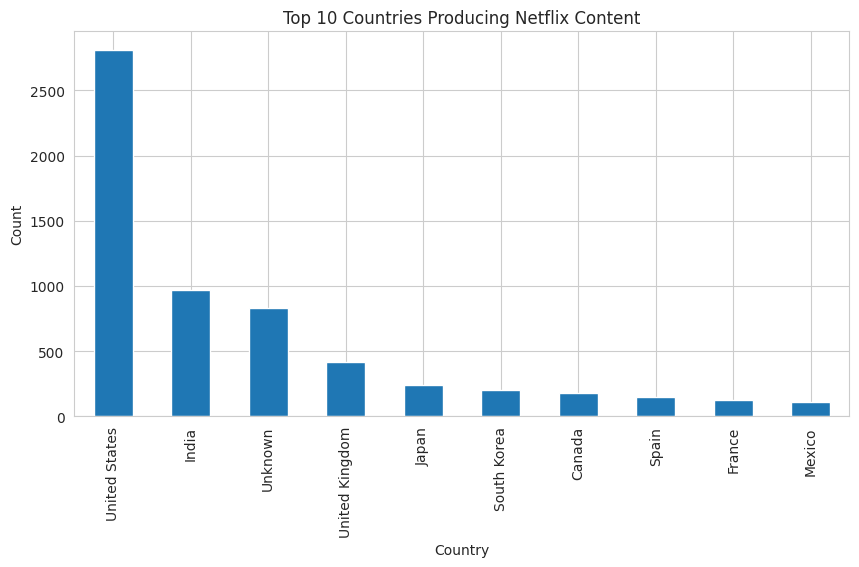

In [11]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

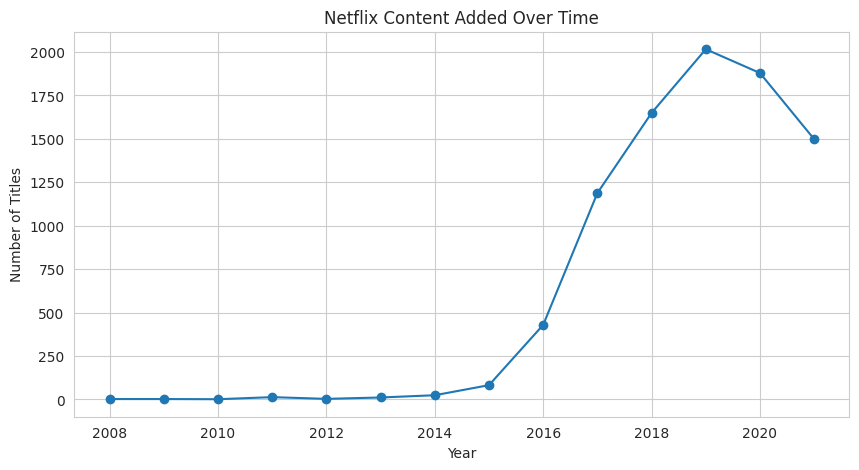

In [12]:
yearly_content = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,5))

yearly_content.plot(marker='o')

plt.title("Netflix Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

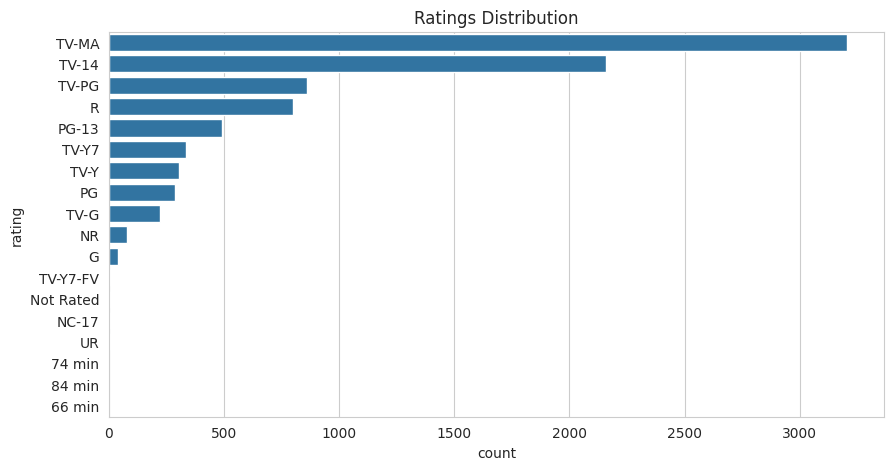

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y='rating',
    order=df['rating'].value_counts().index
)

plt.title("Ratings Distribution")

plt.show()

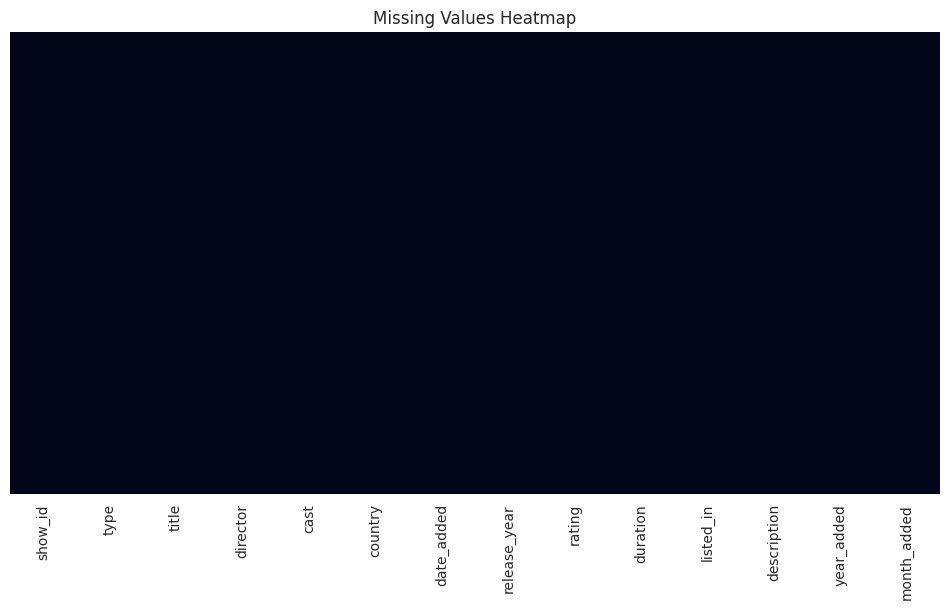

In [14]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")

plt.show()

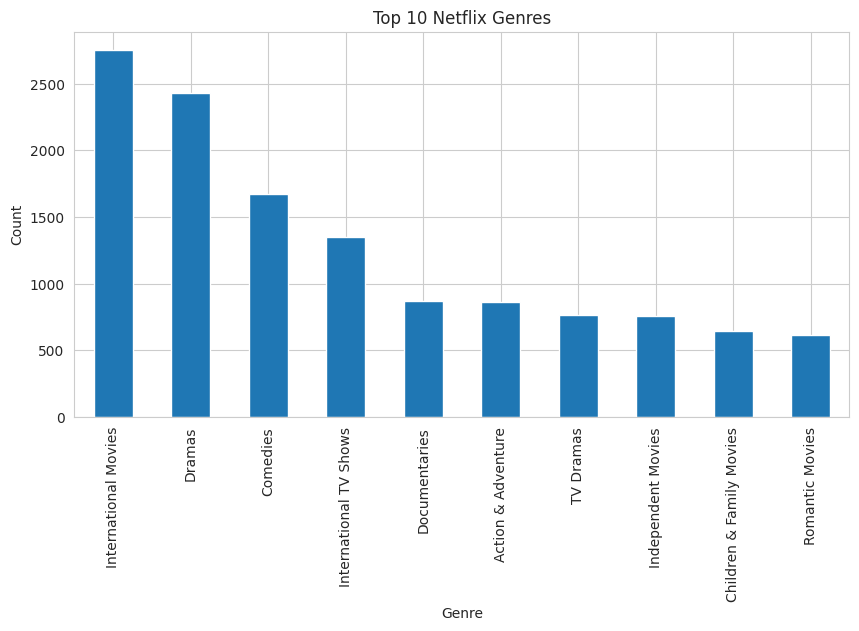

In [15]:
genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,5))

top_genres.plot(kind='bar')

plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

In [16]:
print("""
KEY INSIGHTS

1. Movies are more common than TV Shows.
2. United States contributes the most content.
3. Netflix content increased rapidly after 2015.
4. TV-MA is one of the most common ratings.
5. International Movies and Dramas are highly represented.
""")


KEY INSIGHTS

1. Movies are more common than TV Shows.
2. United States contributes the most content.
3. Netflix content increased rapidly after 2015.
4. TV-MA is one of the most common ratings.
5. International Movies and Dramas are highly represented.



In [17]:
df.to_csv("../cleaned_data/netflix_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [18]:
print("""
PROJECT CONCLUSION

The Netflix dataset was cleaned by handling missing values,
removing duplicates, and converting date fields.

Several visualizations were created to understand trends,
content distribution, ratings, and genre popularity.

This project demonstrates skills in:
- Data Cleaning
- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Data Visualization
- Storytelling with Data
""")


PROJECT CONCLUSION

The Netflix dataset was cleaned by handling missing values,
removing duplicates, and converting date fields.

Several visualizations were created to understand trends,
content distribution, ratings, and genre popularity.

This project demonstrates skills in:
- Data Cleaning
- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Data Visualization
- Storytelling with Data



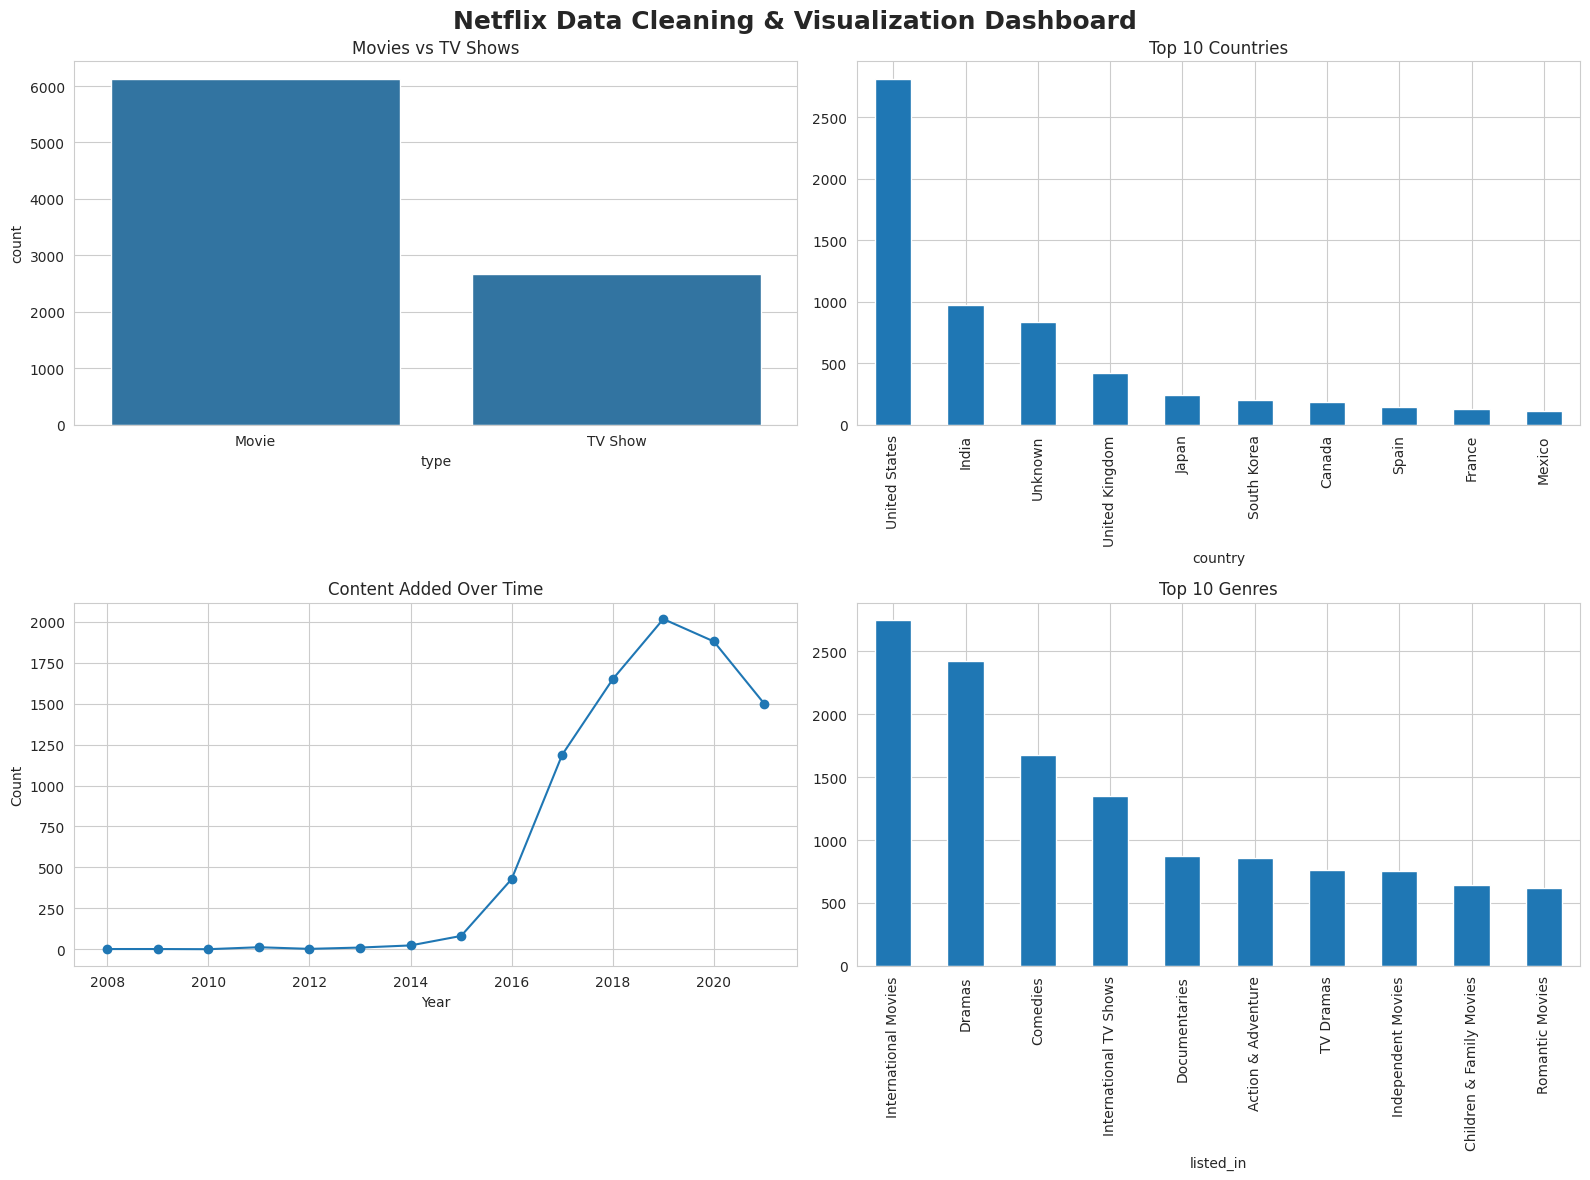

Dashboard saved successfully!
Cleaned dataset saved successfully!


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("../dataset/netflix_titles.csv")

# Data Cleaning
df.drop_duplicates(inplace=True)

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

df['date_added'] = df['date_added'].astype(str).str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df.dropna(subset=['date_added'], inplace=True)

df['year_added'] = df['date_added'].dt.year

# Dashboard Style
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Movies vs TV Shows
sns.countplot(
    data=df,
    x='type',
    ax=axes[0,0]
)
axes[0,0].set_title('Movies vs TV Shows')

# Chart 2: Top 10 Countries
top_countries = df['country'].value_counts().head(10)
top_countries.plot(
    kind='bar',
    ax=axes[0,1]
)
axes[0,1].set_title('Top 10 Countries')

# Chart 3: Content Added Over Time
yearly_content = df['year_added'].value_counts().sort_index()

axes[1,0].plot(
    yearly_content.index,
    yearly_content.values,
    marker='o'
)
axes[1,0].set_title('Content Added Over Time')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Count')

# Chart 4: Top Genres
genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(10)

top_genres.plot(
    kind='bar',
    ax=axes[1,1]
)
axes[1,1].set_title('Top 10 Genres')

plt.suptitle(
    'Netflix Data Cleaning & Visualization Dashboard',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

# Save Dashboard
plt.savefig(
    "../visuals/netflix_dashboard.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Save Cleaned Dataset
df.to_csv(
    "../cleaned_data/netflix_cleaned.csv",
    index=False
)

print("Dashboard saved successfully!")
print("Cleaned dataset saved successfully!")

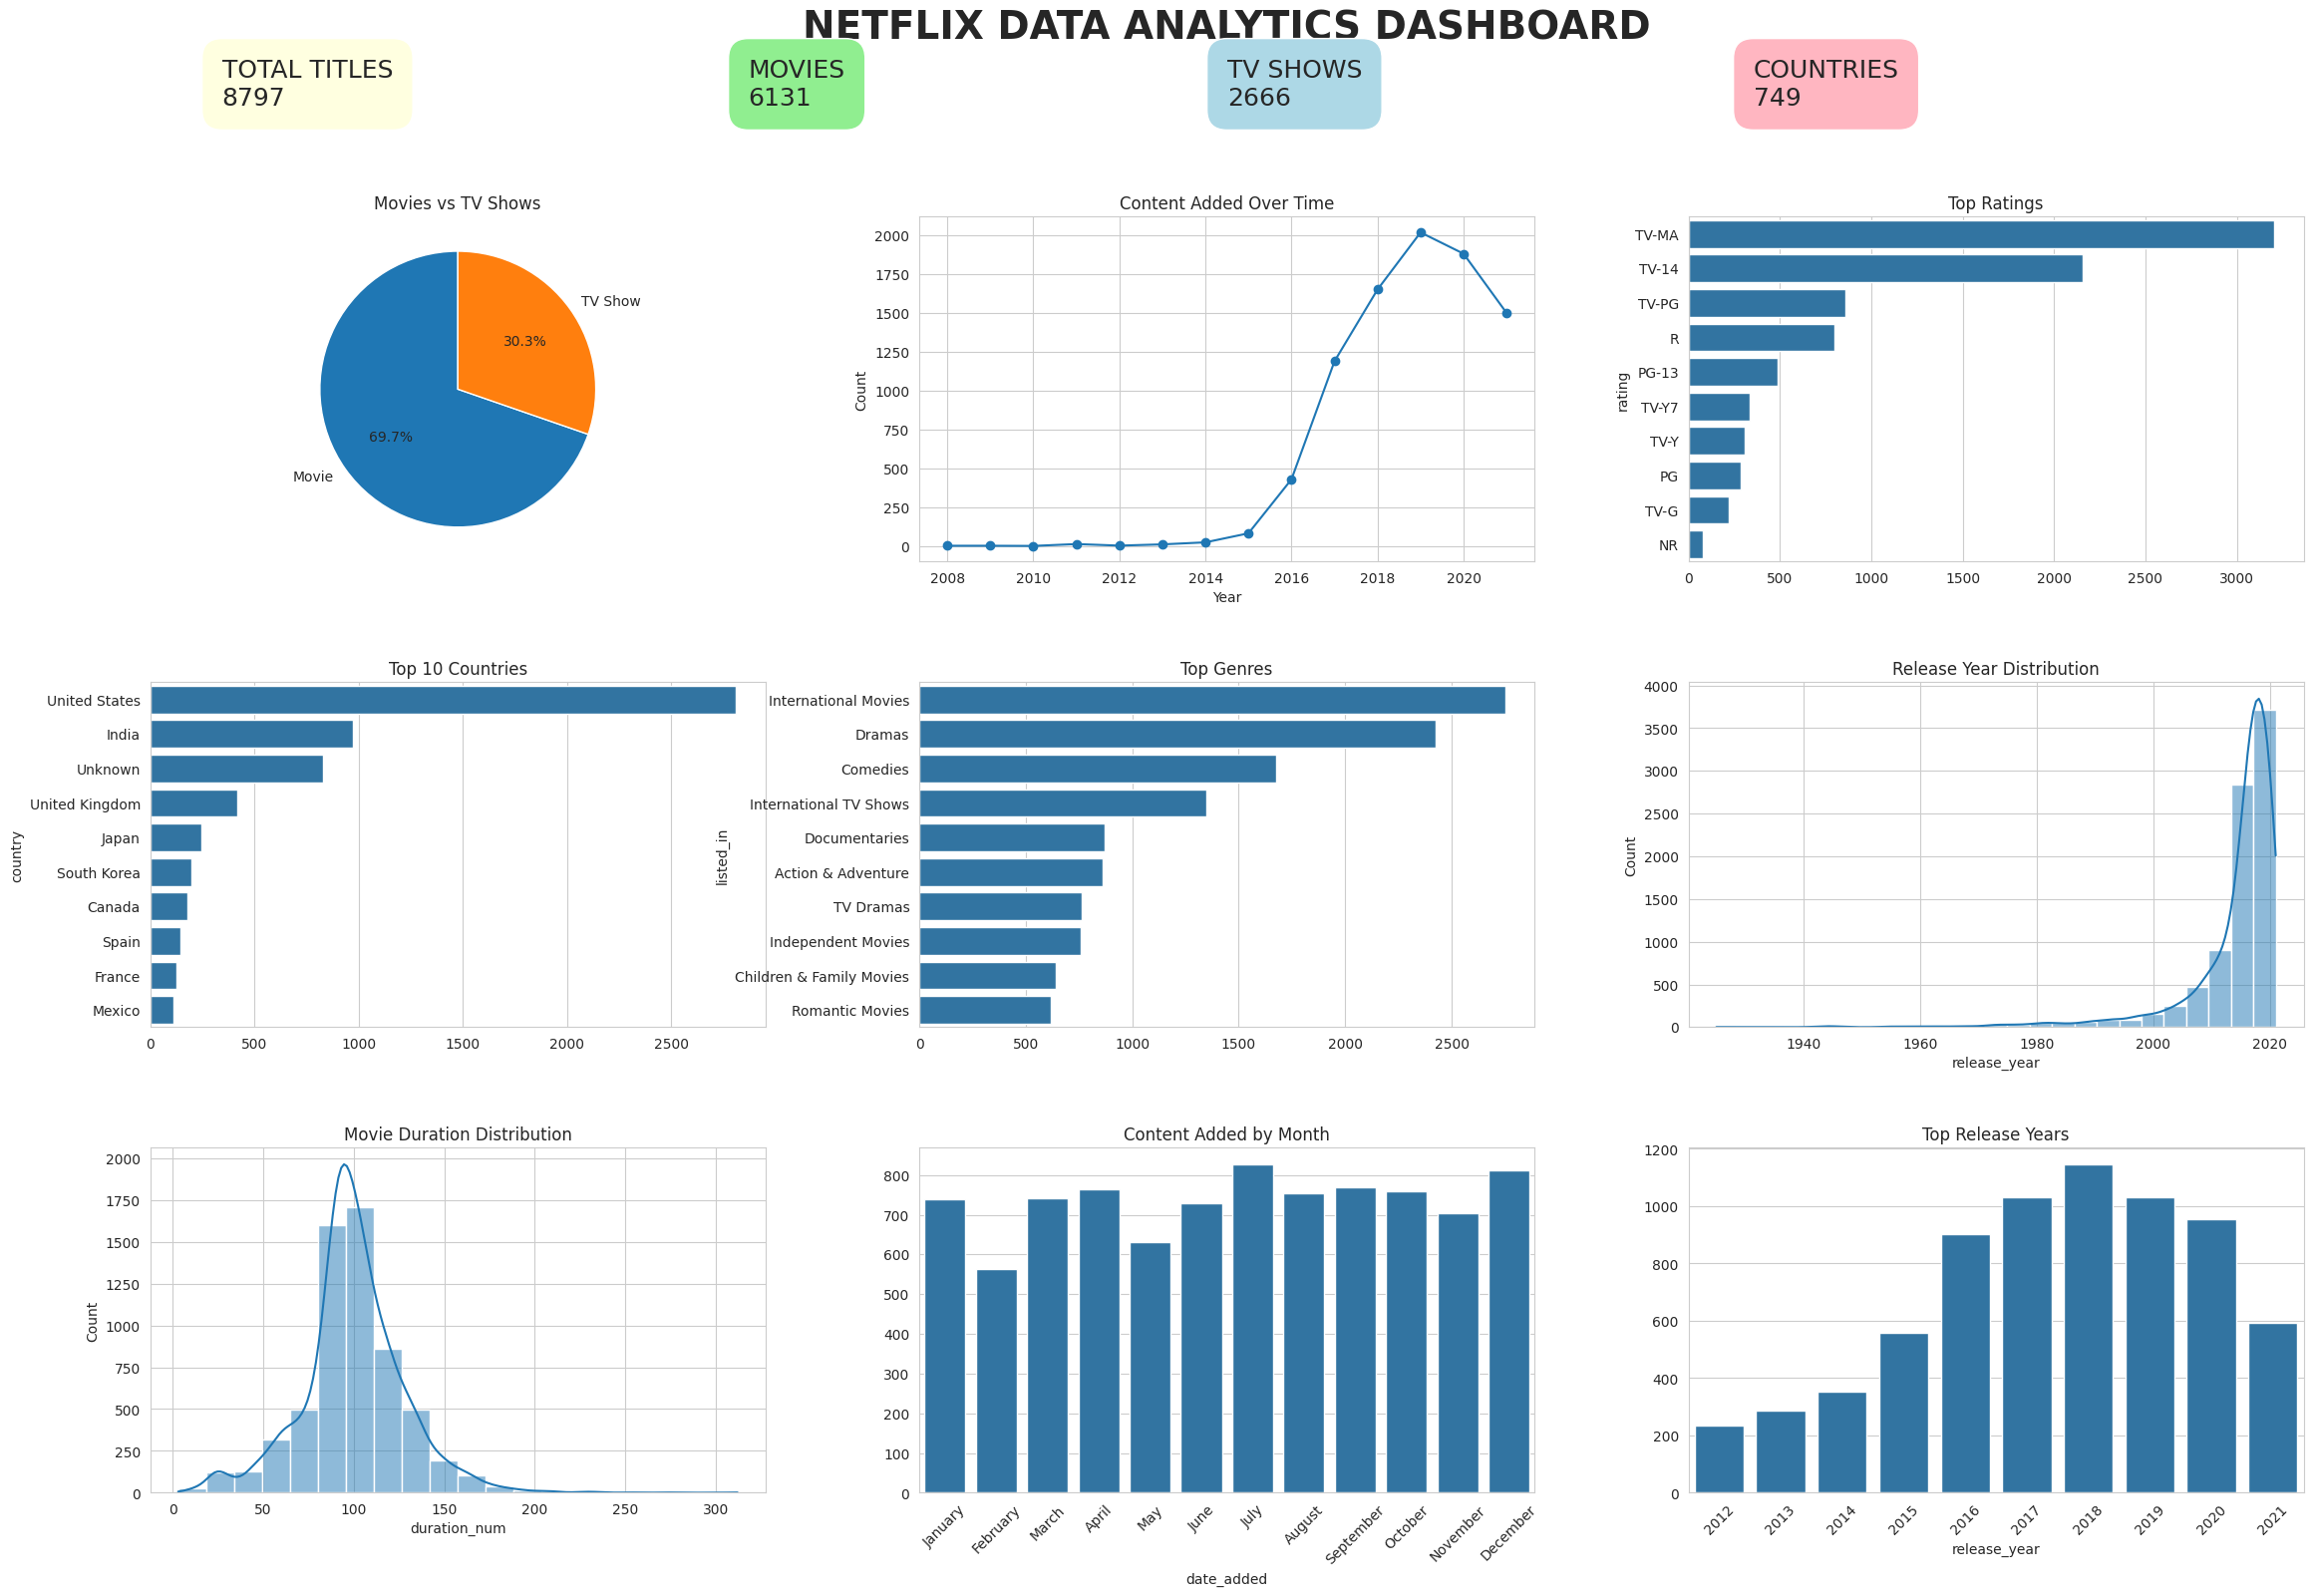

Dashboard saved as netflix_dashboard_pro.png
Cleaned dataset saved as netflix_cleaned.csv


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# LOAD DATASET
# ==========================
df = pd.read_csv("../dataset/netflix_titles.csv")

# ==========================
# DATA CLEANING
# ==========================
df.drop_duplicates(inplace=True)

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

df['date_added'] = df['date_added'].astype(str).str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df.dropna(subset=['date_added'], inplace=True)

df['year_added'] = df['date_added'].dt.year

# ==========================
# KPI VALUES
# ==========================
total_titles = len(df)
movies = len(df[df['type'] == 'Movie'])
tv_shows = len(df[df['type'] == 'TV Show'])
countries = df['country'].nunique()

# ==========================
# DASHBOARD STYLE
# ==========================
sns.set_style("whitegrid")

fig = plt.figure(figsize=(24, 16))
fig.suptitle(
    "NETFLIX DATA ANALYTICS DASHBOARD",
    fontsize=28,
    fontweight='bold'
)

# ==========================
# KPI CARDS
# ==========================
fig.text(
    0.08, 0.92,
    f"TOTAL TITLES\n{total_titles}",
    fontsize=18,
    bbox=dict(boxstyle="round,pad=0.8", fc="lightyellow")
)

fig.text(
    0.30, 0.92,
    f"MOVIES\n{movies}",
    fontsize=18,
    bbox=dict(boxstyle="round,pad=0.8", fc="lightgreen")
)

fig.text(
    0.50, 0.92,
    f"TV SHOWS\n{tv_shows}",
    fontsize=18,
    bbox=dict(boxstyle="round,pad=0.8", fc="lightblue")
)

fig.text(
    0.72, 0.92,
    f"COUNTRIES\n{countries}",
    fontsize=18,
    bbox=dict(boxstyle="round,pad=0.8", fc="lightpink")
)

# ==========================
# SUBPLOTS
# ==========================
gs = fig.add_gridspec(
    3, 3,
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.85,
    hspace=0.35,
    wspace=0.25
)

# --------------------------
# 1 Movies vs TV Shows
# --------------------------
ax1 = fig.add_subplot(gs[0, 0])

type_counts = df['type'].value_counts()

ax1.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

ax1.set_title("Movies vs TV Shows")

# --------------------------
# 2 Content Growth
# --------------------------
ax2 = fig.add_subplot(gs[0, 1])

yearly = df['year_added'].value_counts().sort_index()

ax2.plot(
    yearly.index,
    yearly.values,
    marker='o'
)

ax2.set_title("Content Added Over Time")
ax2.set_xlabel("Year")
ax2.set_ylabel("Count")

# --------------------------
# 3 Ratings Distribution
# --------------------------
ax3 = fig.add_subplot(gs[0, 2])

rating_counts = df['rating'].value_counts().head(10)

sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index,
    ax=ax3
)

ax3.set_title("Top Ratings")

# --------------------------
# 4 Top Countries
# --------------------------
ax4 = fig.add_subplot(gs[1, 0])

country_counts = df['country'].value_counts().head(10)

sns.barplot(
    x=country_counts.values,
    y=country_counts.index,
    ax=ax4
)

ax4.set_title("Top 10 Countries")

# --------------------------
# 5 Top Genres
# --------------------------
ax5 = fig.add_subplot(gs[1, 1])

genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(10)

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    ax=ax5
)

ax5.set_title("Top Genres")

# --------------------------
# 6 Release Year Distribution
# --------------------------
ax6 = fig.add_subplot(gs[1, 2])

sns.histplot(
    df['release_year'],
    bins=25,
    kde=True,
    ax=ax6
)

ax6.set_title("Release Year Distribution")

# --------------------------
# 7 Movie Duration
# --------------------------
ax7 = fig.add_subplot(gs[2, 0])

movie_df = df[df['type'] == 'Movie'].copy()

movie_df['duration_num'] = movie_df['duration'].str.extract('(\d+)')

movie_df['duration_num'] = pd.to_numeric(
    movie_df['duration_num'],
    errors='coerce'
)

sns.histplot(
    movie_df['duration_num'].dropna(),
    bins=20,
    kde=True,
    ax=ax7
)

ax7.set_title("Movie Duration Distribution")

# --------------------------
# 8 Content Added By Month
# --------------------------
ax8 = fig.add_subplot(gs[2, 1])

monthly = df['date_added'].dt.month_name()

monthly_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly = monthly.value_counts().reindex(monthly_order)

sns.barplot(
    x=monthly.index,
    y=monthly.values,
    ax=ax8
)

ax8.tick_params(axis='x', rotation=45)

ax8.set_title("Content Added by Month")

# --------------------------
# 9 Top Release Years
# --------------------------
ax9 = fig.add_subplot(gs[2, 2])

top_years = df['release_year'].value_counts().head(10)

sns.barplot(
    x=top_years.index,
    y=top_years.values,
    ax=ax9
)

ax9.tick_params(axis='x', rotation=45)

ax9.set_title("Top Release Years")

# ==========================
# SAVE DASHBOARD
# ==========================
plt.savefig(
    "../visuals/netflix_dashboard_pro.png",
    dpi=500,
    bbox_inches='tight'
)

plt.show()

# ==========================
# SAVE CLEANED DATA
# ==========================
df.to_csv(
    "../cleaned_data/netflix_cleaned.csv",
    index=False
)

print("Dashboard saved as netflix_dashboard_pro.png")
print("Cleaned dataset saved as netflix_cleaned.csv")

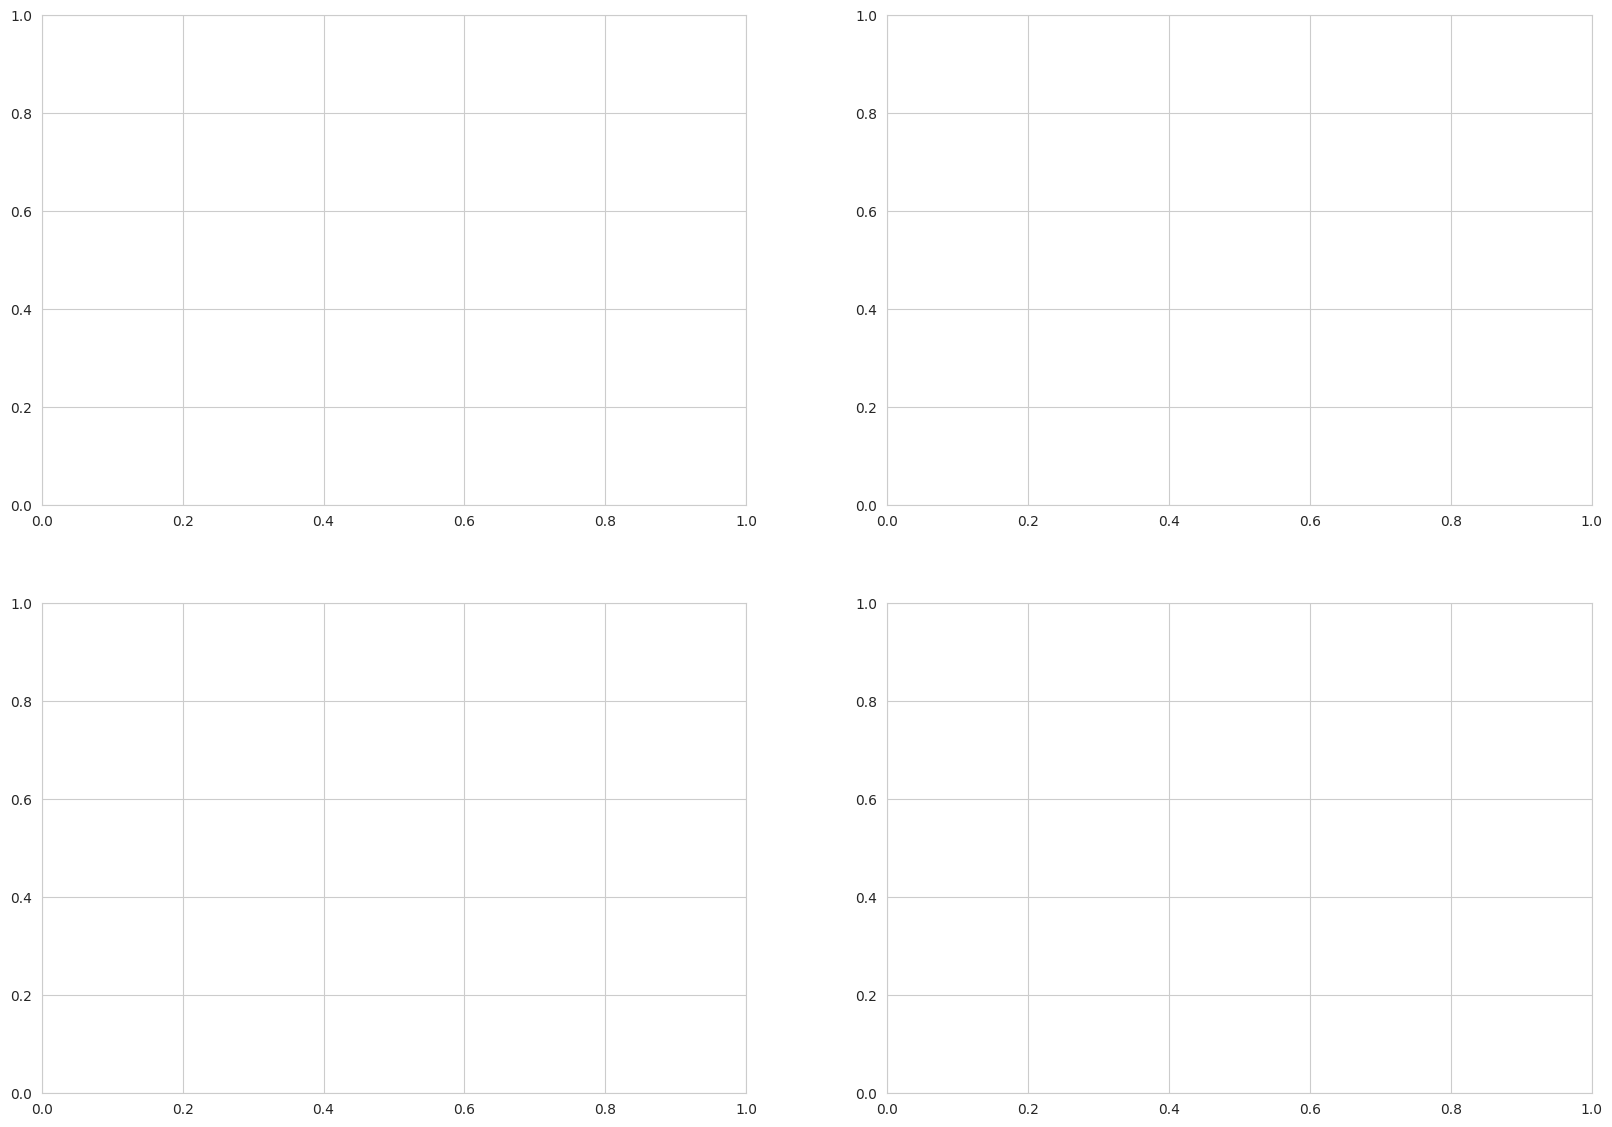

In [21]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(20, 14)
)

In [22]:
plt.savefig(
    "netflix_dashboard.png",
    dpi=600,
    bbox_inches="tight"
)

<Figure size 1000x600 with 0 Axes>

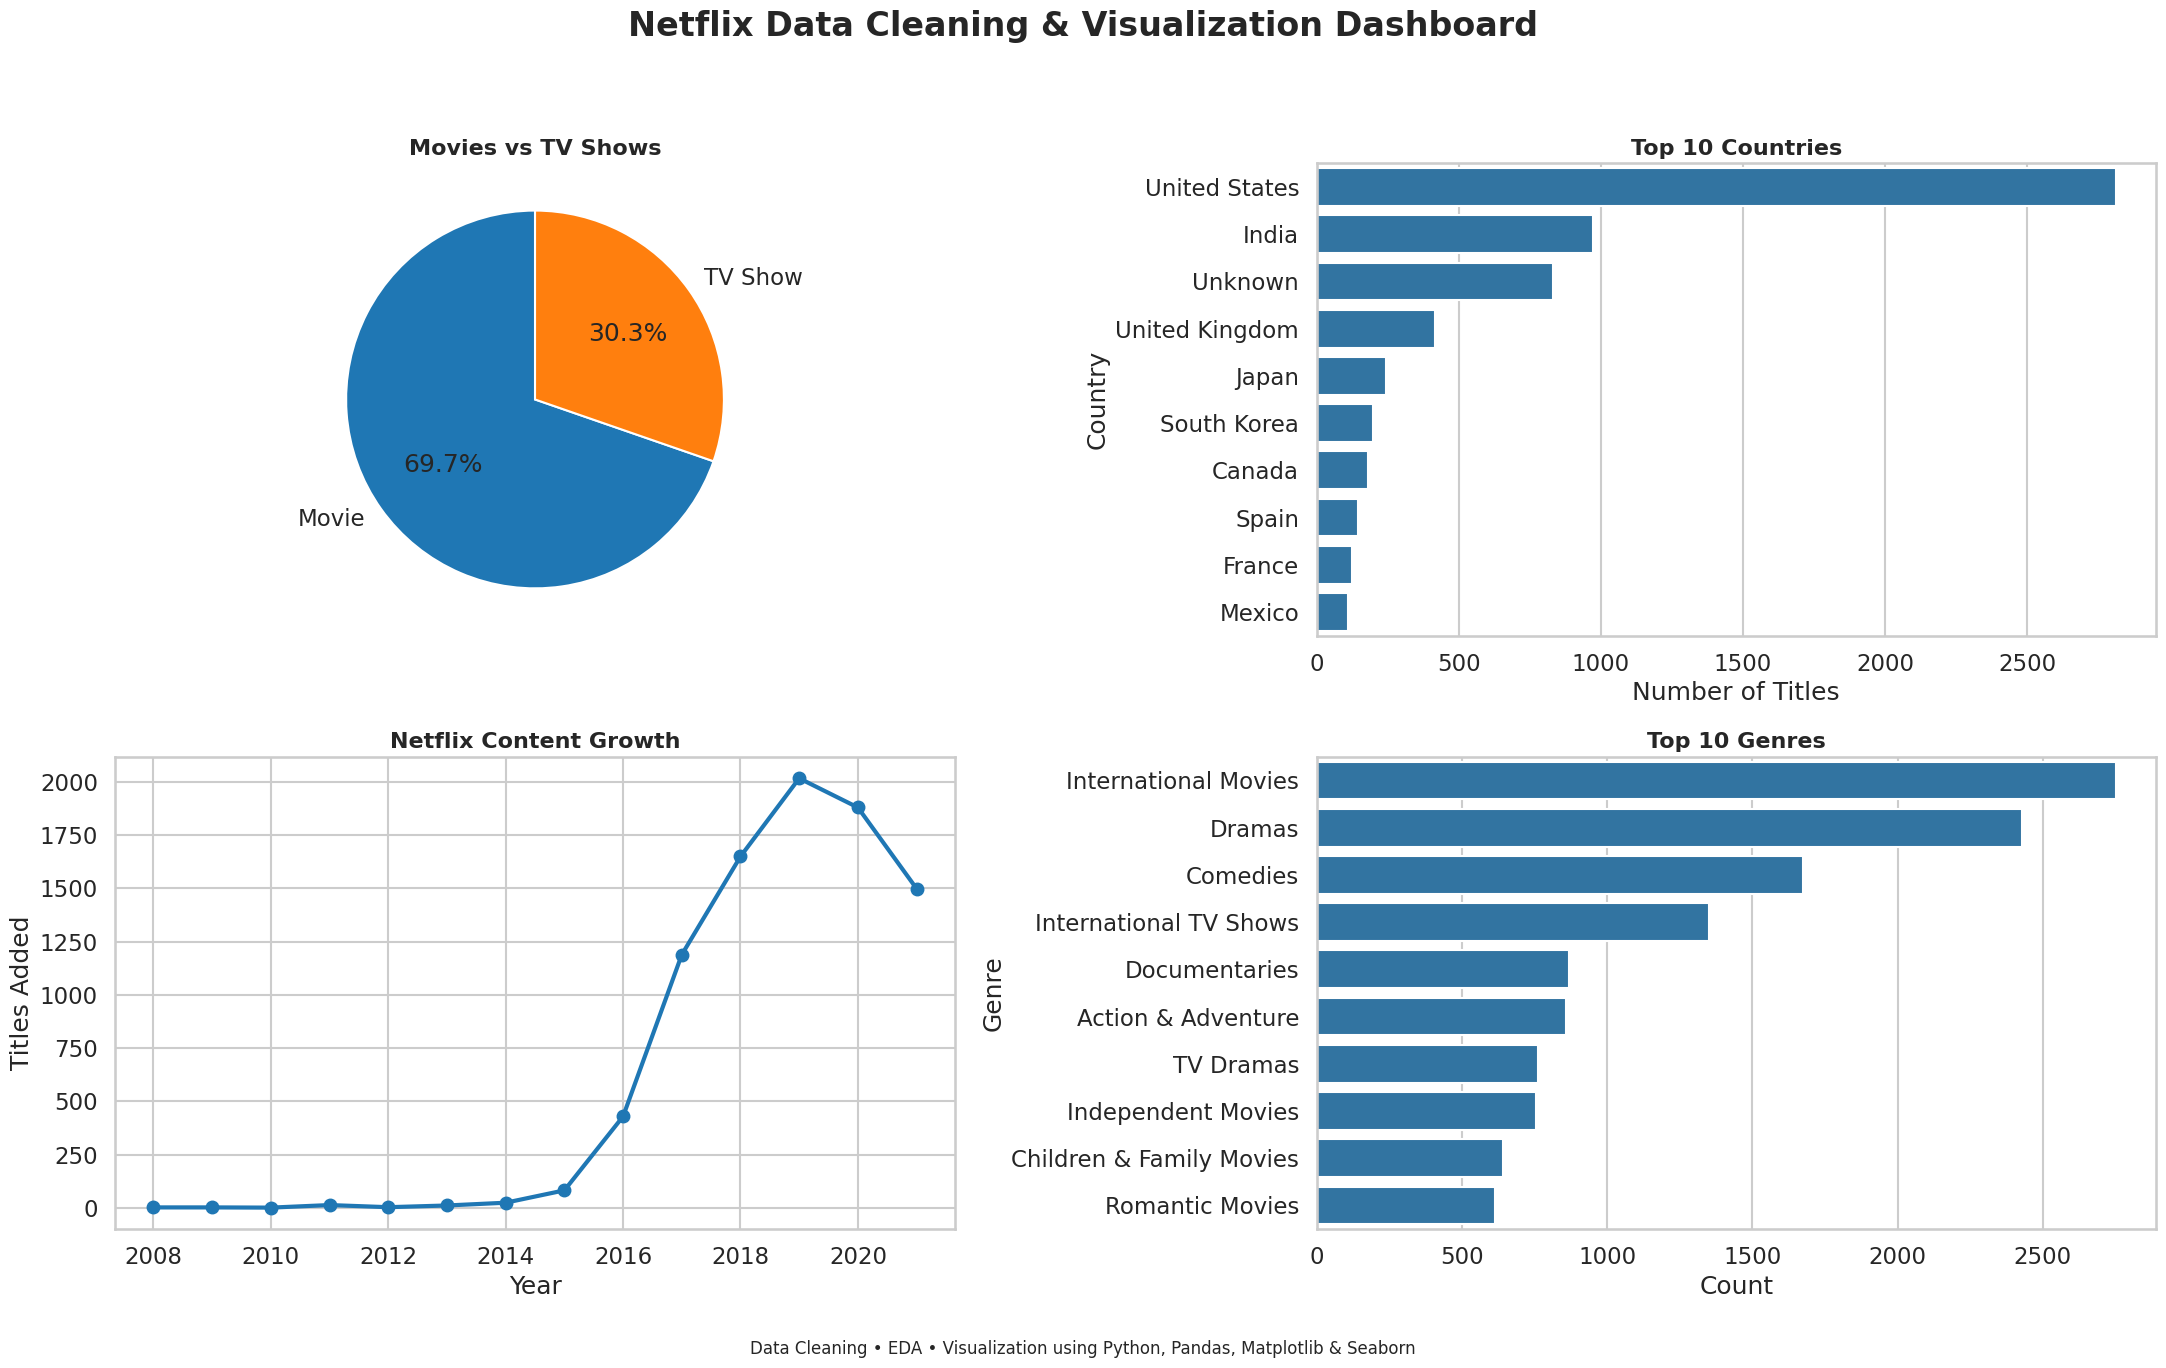

Dashboard saved successfully!
Cleaned dataset saved successfully!


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# LOAD DATA
# ==========================
df = pd.read_csv("../dataset/netflix_titles.csv")

# ==========================
# DATA CLEANING
# ==========================
df.drop_duplicates(inplace=True)

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

df['date_added'] = df['date_added'].astype(str).str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df.dropna(subset=['date_added'], inplace=True)

df['year_added'] = df['date_added'].dt.year

# ==========================
# STYLE
# ==========================
sns.set_style("whitegrid")
sns.set_context("talk")

# ==========================
# CREATE DASHBOARD
# ==========================
fig, axes = plt.subplots(
    2,
    2,
    figsize=(22, 14)
)

fig.suptitle(
    "Netflix Data Cleaning & Visualization Dashboard",
    fontsize=24,
    fontweight='bold'
)

# ==========================
# CHART 1
# Movies vs TV Shows
# ==========================
type_counts = df['type'].value_counts()

axes[0,0].pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

axes[0,0].set_title(
    "Movies vs TV Shows",
    fontsize=16,
    fontweight='bold'
)

# ==========================
# CHART 2
# Top 10 Countries
# ==========================
top_countries = df['country'].value_counts().head(10)

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Top 10 Countries",
    fontsize=16,
    fontweight='bold'
)

axes[0,1].set_xlabel("Number of Titles")
axes[0,1].set_ylabel("Country")

# ==========================
# CHART 3
# Content Growth
# ==========================
yearly = df['year_added'].value_counts().sort_index()

axes[1,0].plot(
    yearly.index,
    yearly.values,
    marker='o',
    linewidth=3
)

axes[1,0].set_title(
    "Netflix Content Growth",
    fontsize=16,
    fontweight='bold'
)

axes[1,0].set_xlabel("Year")
axes[1,0].set_ylabel("Titles Added")

# ==========================
# CHART 4
# Top Genres
# ==========================
genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(10)

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    ax=axes[1,1]
)

axes[1,1].set_title(
    "Top 10 Genres",
    fontsize=16,
    fontweight='bold'
)

axes[1,1].set_xlabel("Count")
axes[1,1].set_ylabel("Genre")

# ==========================
# FOOTER
# ==========================
fig.text(
    0.5,
    0.02,
    "Data Cleaning • EDA • Visualization using Python, Pandas, Matplotlib & Seaborn",
    ha='center',
    fontsize=12
)

# ==========================
# LAYOUT
# ==========================
plt.tight_layout(rect=[0, 0.04, 1, 0.95])

# ==========================
# SAVE IMAGE
# ==========================
plt.savefig(
    "../visuals/netflix_linkedin_dashboard.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

# ==========================
# SAVE CLEANED DATA
# ==========================
df.to_csv(
    "../cleaned_data/netflix_cleaned.csv",
    index=False
)

print("Dashboard saved successfully!")
print("Cleaned dataset saved successfully!")